# Raw Otsu: development experiment and evaluation

This notebook is the complete development interface for raw Otsu. It verifies the manifest, runs or reloads all 139 development records, evaluates detections against XML annotations, and visualises class performance, runtime, thresholds, fragmentation, and representative images. It never selects validation or test rows.

In [1]:
import json
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / 'data' / 'dataset_split.csv').is_file()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from algorithms.common import load_image
from algorithms.evaluation import parse_voc_boxes
from algorithms.otsu import detect_otsu
from scripts.development.run_otsu_development import (
    evaluate_records,
    load_development_rows,
    summarise,
    write_results,
)

plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 30)

## 1. Development baseline configuration (not frozen)

Development is used to implement and debug this baseline and to identify defensible candidate settings. Final parameter and matching-rule selection belongs to validation. Otsu's intensity threshold is selected automatically for every difference image; it is an output, not a tuned hyperparameter. `IOU_THRESHOLD = 0.50` is only a provisional one-to-one diagnostic rule. The raw pipeline uses no blur, resizing, morphology, contour-area filtering, or region merging.

In [2]:
MANIFEST_PATH = PROJECT_ROOT / 'data' / 'dataset_split.csv'
RESULTS_PATH = PROJECT_ROOT / 'outputs' / 'metrics' / 'otsu_development.csv'
SUMMARY_PATH = PROJECT_ROOT / 'outputs' / 'metrics' / 'otsu_development_summary.json'
BOXES_DIR = PROJECT_ROOT / 'outputs' / 'metrics' / 'otsu_development_boxes'
IOU_THRESHOLD = 0.50
RUN_DEVELOPMENT = False  # Set True to recompute all 139 full-resolution images.

development_baseline = {
    'input': 'aligned reference and defective image pair',
    'shared_preprocessing': 'dimension validation and grayscale conversion',
    'comparison': 'cv2.absdiff',
    'threshold': 'cv2.THRESH_BINARY + cv2.THRESH_OTSU (automatic per image)',
    'contours': 'cv2.RETR_EXTERNAL + cv2.CHAIN_APPROX_SIMPLE',
    'post_processing': 'none',
    'evaluation_iou': IOU_THRESHOLD,
}
pd.Series(development_baseline, name='setting').to_frame()

,setting
input,aligned reference and defective image pair
shared_preprocessing,dimension validation and grayscale conversion
comparison,cv2.absdiff
threshold,cv2.THRESH_BINARY + cv2.THRESH_OTSU (automatic...
contours,cv2.RETR_EXTERNAL + cv2.CHAIN_APPROX_SIMPLE
post_processing,none
evaluation_iou,0.5


## 2. Manifest and development-split verification

,images
split,
development,139
validation,139
test,415


,development_images
defect_class,
missing_hole,23
mouse_bite,23
open_circuit,24
short_circuit,23
spur,23
spurious_copper,23


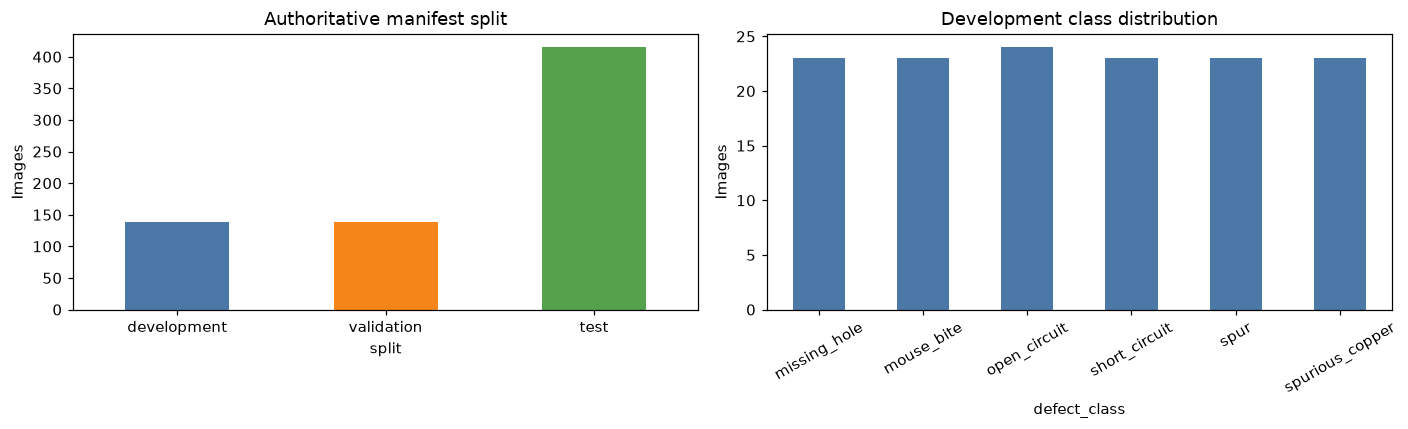

In [3]:
manifest_df = pd.read_csv(MANIFEST_PATH)
development_df = manifest_df.loc[manifest_df['split'].eq('development')].copy()

assert len(manifest_df) == 693
assert len(development_df) == 139
assert set(development_df['split']) == {'development'}
assert development_df['image_id'].is_unique

split_counts = manifest_df['split'].value_counts().reindex(
    ['development', 'validation', 'test']
)
class_counts = development_df['defect_class'].value_counts().sort_index()
display(split_counts.rename('images').to_frame())
display(class_counts.rename('development_images').to_frame())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
split_counts.plot.bar(ax=axes[0], color=['#4C78A8', '#F58518', '#54A24B'])
axes[0].set_title('Authoritative manifest split')
axes[0].set_ylabel('Images')
axes[0].tick_params(axis='x', rotation=0)
class_counts.plot.bar(ax=axes[1], color='#4C78A8')
axes[1].set_title('Development class distribution')
axes[1].set_ylabel('Images')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 3. Execute or reload the development experiment

The existing verified outputs are loaded by default. Set `RUN_DEVELOPMENT = True` to rerun the complete full-resolution experiment. Complete unfiltered predicted boxes are stored in typed NumPy sidecars because raw Otsu produced more than 25 million contours.

In [4]:
outputs_exist = RESULTS_PATH.is_file() and SUMMARY_PATH.is_file()
if RUN_DEVELOPMENT or not outputs_exist:
    development_rows = load_development_rows(MANIFEST_PATH)
    results = evaluate_records(
        development_rows,
        IOU_THRESHOLD,
        workers=1,
        boxes_directory=BOXES_DIR,
    )
    summary = summarise(results, IOU_THRESHOLD)
    write_results(results, RESULTS_PATH)
    SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)
    SUMMARY_PATH.write_text(
        json.dumps(summary, indent=2, sort_keys=True) + '\n',
        encoding='utf-8',
    )
    print('Development experiment completed and saved.')
else:
    print('Loading the existing verified development results.')

Loading the existing verified development results.


In [5]:
results_df = pd.read_csv(RESULTS_PATH)
summary = json.loads(SUMMARY_PATH.read_text(encoding='utf-8'))

assert len(results_df) == 139
assert set(results_df['split']) == {'development'}
assert set(results_df['status']) == {'success'}
assert summary['records'] == summary['successful'] == 139
assert summary['errors'] == 0
assert np.isclose(summary['iou_threshold'], IOU_THRESHOLD)
assert results_df['predicted_boxes_path'].map(
    lambda path: (PROJECT_ROOT / path).is_file()
).all()

print('Verified result rows:', len(results_df))
print('Errors:', summary['errors'])
results_df.head()

Verified result rows: 139
Errors: 0


,image_id,defect_class,split,algorithm_version,otsu_threshold,predicted_count,ground_truth_count,true_positives,false_positives,false_negatives,precision,recall,f1_score,mean_matched_iou,iou_threshold,white_pixel_percentage,processing_time_ms,predicted_boxes_path,ground_truth_boxes,status,error
0,01_missing_hole_02,missing_hole,development,raw-otsu-v1,44.0,3,3,0,3,3,0.000000,0.000000,0.000000,0.000000,0.5,0.035952,25.2063,outputs/metrics/otsu_development_boxes/01_miss...,"[{""class"":""missing_hole"",""xmin"":2584,""ymin"":23...",success,NaN
1,01_missing_hole_10,missing_hole,development,raw-otsu-v1,37.0,4,3,0,4,3,0.000000,0.000000,0.000000,0.000000,0.5,0.033459,12.8152,outputs/metrics/otsu_development_boxes/01_miss...,"[{""class"":""missing_hole"",""xmin"":1624,""ymin"":40...",success,NaN
2,01_missing_hole_17,missing_hole,development,raw-otsu-v1,40.0,4,3,0,4,3,0.000000,0.000000,0.000000,0.000000,0.5,0.036908,13.0000,outputs/metrics/otsu_development_boxes/01_miss...,"[{""class"":""missing_hole"",""xmin"":917,""ymin"":292...",success,NaN
3,01_mouse_bite_01,mouse_bite,development,raw-otsu-v1,1.0,124688,3,1,124687,2,0.000008,0.333333,0.000016,0.564252,0.5,34.155298,679.5128,outputs/metrics/otsu_development_boxes/01_mous...,"[{""class"":""mouse_bite"",""xmin"":1518,""ymin"":913,...",success,NaN
4,01_mouse_bite_15,mouse_bite,development,raw-otsu-v1,1.0,124692,2,0,124692,2,0.000000,0.000000,0.000000,0.000000,0.5,34.155631,713.3520,outputs/metrics/otsu_development_boxes/01_mous...,"[{""class"":""mouse_bite"",""xmin"":601,""ymin"":1053,...",success,NaN


## 4. Overall development evaluation

Object-detection metrics use greedy one-to-one matching at IoU 0.50. True negatives and classification accuracy are not defined for this direct contour-detection output, so precision, recall, F1, matched IoU, false positives, and false negatives are reported.

In [6]:
overall_metrics = pd.Series(
    summary['overall_box_metrics'], name='raw_otsu'
).to_frame()

runtime_metrics = pd.Series(
    summary['runtime_ms'], name='raw_otsu'
).to_frame()

display(overall_metrics.round(7))
display(runtime_metrics.round(7))

,raw_otsu
f1_score,1.460000e-05
false_negatives,4.140000e+02
false_positives,2.527902e+07
images,1.390000e+02
mean_image_iou,3.566039e-01
precision,7.300000e-06
recall,3.088481e-01
true_positives,1.850000e+02


,raw_otsu
frames_per_second,0.412408
maximum,4929.527800
mean,2424.781383
minimum,12.815200
standard_deviation,1770.926139


,f1_score,false_negatives,false_positives,images,mean_image_iou,precision,recall,true_positives
defect_class,,,,,,,,
missing_hole,0.000018,98.0,341456.0,23.0,0.026822,0.000009,0.029703,3.0
mouse_bite,0.000019,50.0,4962113.0,23.0,0.454475,0.000009,0.484536,47.0
open_circuit,0.000019,48.0,5799429.0,24.0,0.560737,0.000009,0.529412,54.0
short_circuit,0.000012,69.0,5396700.0,23.0,0.399725,0.000006,0.323529,33.0
spur,0.000014,69.0,4360411.0,23.0,0.361732,0.000007,0.303030,30.0
spurious_copper,0.000008,80.0,4418909.0,23.0,0.327256,0.000004,0.183673,18.0


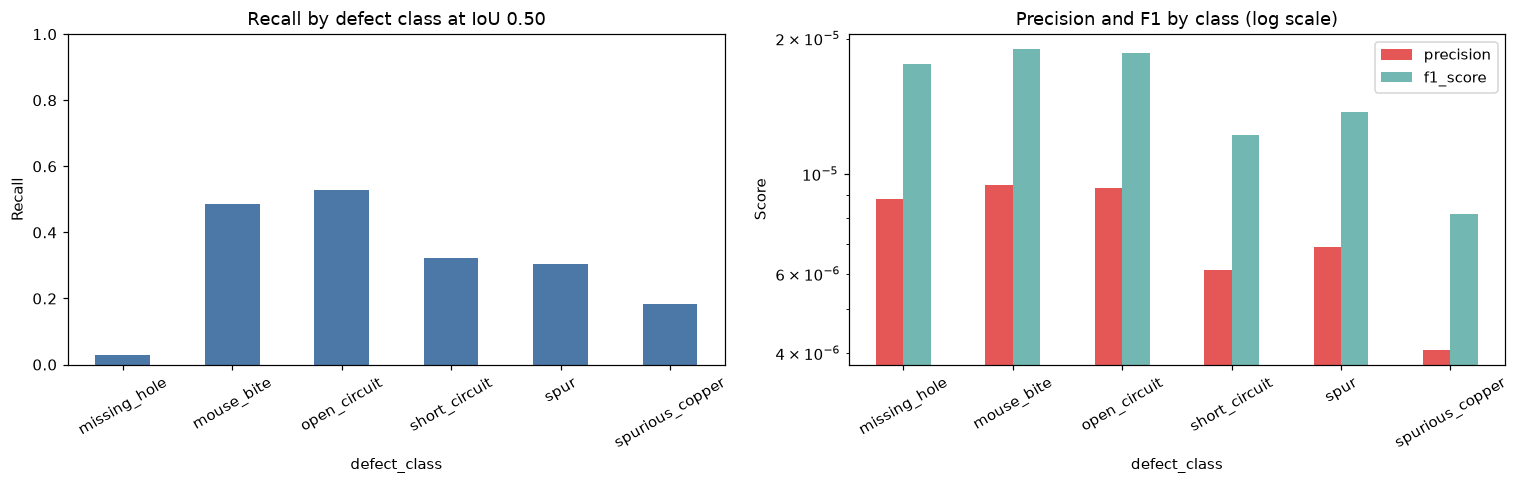

In [7]:
class_metrics_df = pd.DataFrame(summary['box_metrics_by_class']).T
class_metrics_df.index.name = 'defect_class'
display(class_metrics_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
class_metrics_df['recall'].plot.bar(ax=axes[0], color='#4C78A8')
axes[0].set_title('Recall by defect class at IoU 0.50')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Recall')
axes[0].tick_params(axis='x', rotation=30)
class_metrics_df[['precision', 'f1_score']].plot.bar(
    ax=axes[1], color=['#E45756', '#72B7B2']
)
axes[1].set_yscale('log')
axes[1].set_title('Precision and F1 by class (log scale)')
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 5. Otsu thresholds, fragmentation, and runtime

The threshold plot describes Otsu's automatic choices; it is not a manual parameter search. Predicted-region counts use a logarithmic scale because raw differences can generate hundreds of thousands of one-pixel or tiny contours.

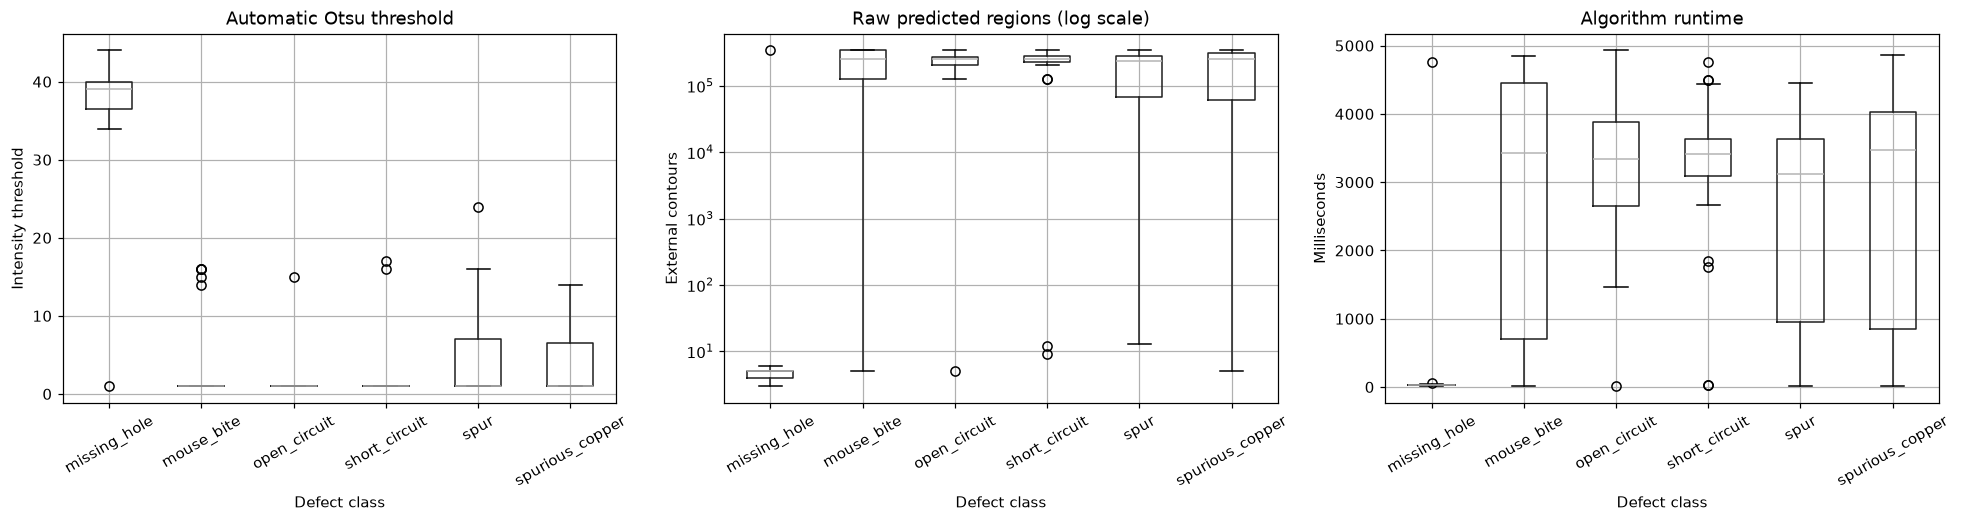

In [8]:
class_order = sorted(results_df['defect_class'].unique())
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
results_df.boxplot(
    column='otsu_threshold', by='defect_class', ax=axes[0], rot=30
)
axes[0].set_title('Automatic Otsu threshold')
axes[0].set_xlabel('Defect class')
axes[0].set_ylabel('Intensity threshold')
results_df.boxplot(
    column='predicted_count', by='defect_class', ax=axes[1], rot=30
)
axes[1].set_yscale('symlog', linthresh=1)
axes[1].set_title('Raw predicted regions (log scale)')
axes[1].set_xlabel('Defect class')
axes[1].set_ylabel('External contours')
results_df.boxplot(
    column='processing_time_ms', by='defect_class', ax=axes[2], rot=30
)
axes[2].set_title('Algorithm runtime')
axes[2].set_xlabel('Defect class')
axes[2].set_ylabel('Milliseconds')
fig.suptitle('')
plt.tight_layout()
plt.show()

In [9]:
fragmentation_summary = results_df.groupby('defect_class').agg(
    images=('image_id', 'size'),
    median_threshold=('otsu_threshold', 'median'),
    median_regions=('predicted_count', 'median'),
    maximum_regions=('predicted_count', 'max'),
    mean_runtime_ms=('processing_time_ms', 'mean'),
    recall=('recall', 'mean'),
)
fragmentation_summary

,images,median_threshold,median_regions,maximum_regions,mean_runtime_ms,recall
defect_class,,,,,,
missing_hole,23,39.0,5.0,341357,235.450348,0.043478
mouse_bite,23,1.0,257656.0,341171,2833.040613,0.507246
open_circuit,24,1.0,257653.0,341224,3243.294579,0.527778
short_circuit,23,1.0,257634.0,341327,3137.034565,0.302899
spur,23,1.0,233059.0,341267,2490.278939,0.307246
spurious_copper,23,1.0,257622.0,341300,2574.001722,0.208696


## 6. Per-image results and representative visualisations

In [10]:
result_columns = [
    'image_id', 'defect_class', 'otsu_threshold', 'predicted_count',
    'ground_truth_count', 'true_positives', 'false_positives',
    'false_negatives', 'precision', 'recall', 'f1_score',
    'mean_matched_iou', 'processing_time_ms',
]
print('Highest matched-IoU development examples')
display(
    results_df.sort_values(
        ['mean_matched_iou', 'recall'], ascending=False
    )[result_columns].head(10)
)
print('Most fragmented development examples')
display(
    results_df.sort_values('predicted_count', ascending=False)[
        result_columns
    ].head(10)
)

Highest matched-IoU development examples


,image_id,defect_class,otsu_threshold,predicted_count,ground_truth_count,true_positives,false_positives,false_negatives,precision,recall,f1_score,mean_matched_iou,processing_time_ms
62,06_short_06,short_circuit,1.0,257660,5,2,257658,3,0.000008,0.400000,0.000016,0.814518,3544.0108
47,04_spurious_copper_20,spurious_copper,1.0,341212,3,2,341210,1,0.000006,0.666667,0.000012,0.759292,4570.9913
61,06_open_circuit_10,open_circuit,1.0,257600,5,3,257597,2,0.000012,0.600000,0.000023,0.757185,3610.2246
99,09_open_circuit_04,open_circuit,1.0,252760,5,2,252758,3,0.000008,0.400000,0.000016,0.754149,3414.2350
59,06_open_circuit_05,open_circuit,1.0,257714,5,3,257711,2,0.000012,0.600000,0.000023,0.740389,3399.2091
21,04_mouse_bite_06,mouse_bite,1.0,341063,3,3,341060,0,0.000009,1.000000,0.000018,0.729079,4698.0859
42,04_spurious_copper_04,spurious_copper,1.0,341300,3,1,341299,2,0.000003,0.333333,0.000006,0.724114,4450.9961
52,05_open_circuit_07,open_circuit,1.0,233124,3,1,233123,2,0.000004,0.333333,0.000009,0.720993,3064.2317
9,01_short_17,short_circuit,1.0,124658,4,2,124656,2,0.000016,0.500000,0.000032,0.714989,1755.0858
13,01_spurious_copper_10,spurious_copper,1.0,124505,3,2,124503,1,0.000016,0.666667,0.000032,0.710418,1936.1940


Most fragmented development examples


,image_id,defect_class,otsu_threshold,predicted_count,ground_truth_count,true_positives,false_positives,false_negatives,precision,recall,f1_score,mean_matched_iou,processing_time_ms
19,04_missing_hole_13,missing_hole,1.0,341357,3,3,341354,0,0.000009,1.000000,0.000018,0.616910,4766.7704
34,04_short_04,short_circuit,1.0,341327,3,0,341327,3,0.000000,0.000000,0.000000,0.000000,4435.7756
35,04_short_06,short_circuit,1.0,341326,3,0,341326,3,0.000000,0.000000,0.000000,0.000000,4497.0228
42,04_spurious_copper_04,spurious_copper,1.0,341300,3,1,341299,2,0.000003,0.333333,0.000006,0.724114,4450.9961
36,04_short_09,short_circuit,1.0,341292,3,0,341292,3,0.000000,0.000000,0.000000,0.000000,4492.8890
43,04_spurious_copper_05,spurious_copper,1.0,341284,3,0,341284,3,0.000000,0.000000,0.000000,0.000000,4476.9440
37,04_spur_05,spur,1.0,341267,3,2,341265,1,0.000006,0.666667,0.000012,0.598328,4363.6694
33,04_short_02,short_circuit,1.0,341253,3,0,341253,3,0.000000,0.000000,0.000000,0.000000,4766.5167
29,04_open_circuit_07,open_circuit,1.0,341224,3,3,341221,0,0.000009,1.000000,0.000018,0.684490,4651.5919
38,04_spur_07,spur,1.0,341222,3,1,341221,2,0.000003,0.333333,0.000006,0.542636,4334.9702


In [11]:
def show_development_result(image_id, maximum_drawn_boxes=500):
    manifest_row = development_df.loc[
        development_df['image_id'].eq(image_id)
    ].iloc[0]
    result_row = results_df.loc[results_df['image_id'].eq(image_id)].iloc[0]
    reference = load_image(PROJECT_ROOT / manifest_row['reference_path'])
    defective = load_image(PROJECT_ROOT / manifest_row['image_path'])
    ground_truth = parse_voc_boxes(
        PROJECT_ROOT / manifest_row['annotation_path']
    )
    detection = detect_otsu(reference, defective)
    overlay = defective.copy()

    for box in ground_truth:
        cv2.rectangle(
            overlay,
            (int(box['xmin']), int(box['ymin'])),
            (int(box['xmax']), int(box['ymax'])),
            (0, 0, 255),
            4,
        )
    boxes_drawn = len(detection.boxes) <= maximum_drawn_boxes
    if boxes_drawn:
        for box in detection.boxes:
            cv2.rectangle(
                overlay,
                (int(box['xmin']), int(box['ymin'])),
                (int(box['xmax']), int(box['ymax'])),
                (0, 255, 0),
                2,
            )

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    axes[0].imshow(cv2.cvtColor(reference, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Reference')
    axes[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    overlay_note = 'GT red; predictions green' if boxes_drawn else 'GT red; boxes omitted from display'
    axes[1].set_title(overlay_note)
    axes[2].imshow(detection.difference, cmap='gray')
    axes[2].set_title(f'Absolute difference; Otsu={detection.threshold:.0f}')
    axes[3].imshow(detection.mask, cmap='gray')
    axes[3].set_title(f"Raw mask; {int(result_row['predicted_count']):,} contours")
    for axis in axes:
        axis.axis('off')
    fig.suptitle(
        f"{image_id} | class={manifest_row['defect_class']} | "
        f"recall={result_row['recall']:.3f} | "
        f"mean matched IoU={result_row['mean_matched_iou']:.3f}"
    )
    plt.tight_layout()
    plt.show()

    return result_row[result_columns].to_frame(name='value')

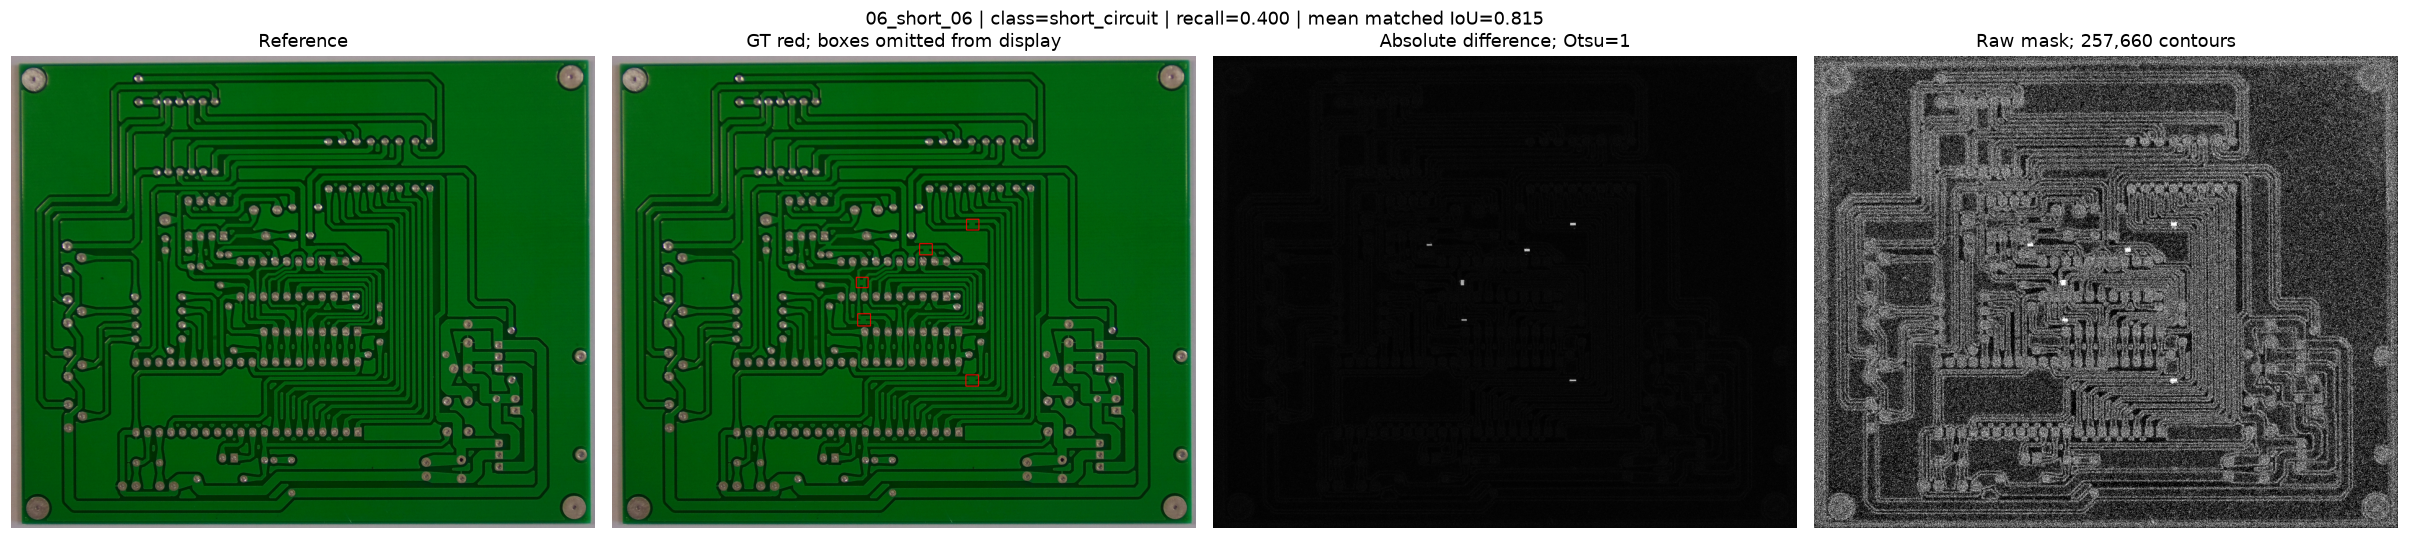

,value
image_id,06_short_06
defect_class,short_circuit
otsu_threshold,1.0
predicted_count,257660
ground_truth_count,5
true_positives,2
false_positives,257658
false_negatives,3
precision,0.000008
recall,0.4


In [12]:
best_image_id = results_df.sort_values(
    ['mean_matched_iou', 'recall'], ascending=False
).iloc[0]['image_id']
show_development_result(best_image_id)

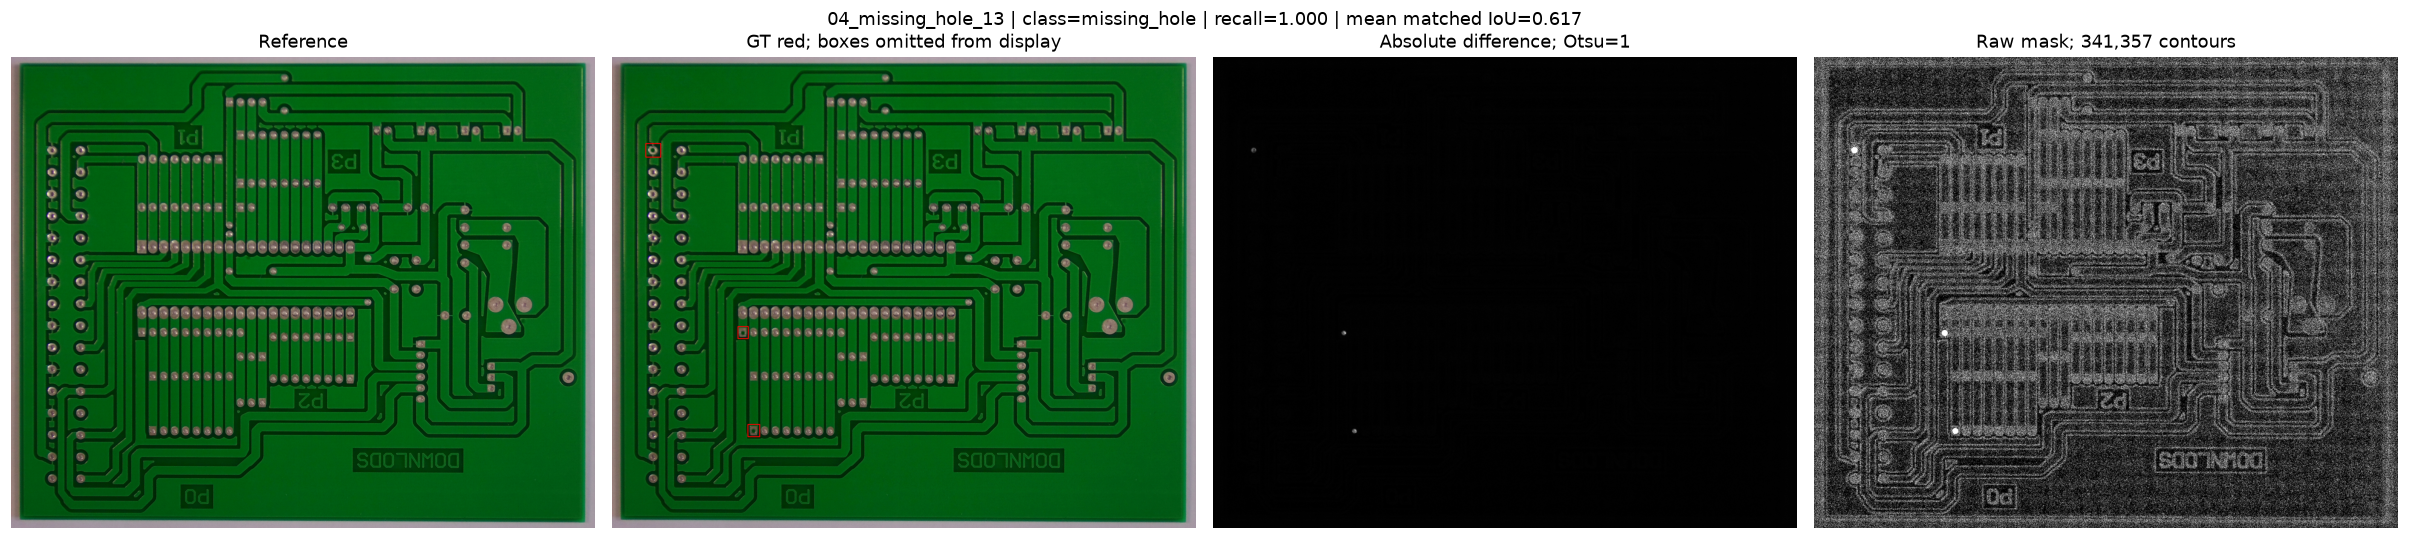

,value
image_id,04_missing_hole_13
defect_class,missing_hole
otsu_threshold,1.0
predicted_count,341357
ground_truth_count,3
true_positives,3
false_positives,341354
false_negatives,0
precision,0.000009
recall,1.0


In [13]:
most_fragmented_image_id = results_df.sort_values(
    'predicted_count', ascending=False
).iloc[0]['image_id']
show_development_result(most_fragmented_image_id)

## 7. Development conclusion

Raw Otsu baseline development is implemented and debugged, but its configuration is not yet validation-frozen and no parameter has been selected to maximise IoU. Otsu chooses its threshold automatically and the experiment intentionally forbids blur, morphology, contour filtering, and merging. The provisional IoU 0.50 rule evaluates localisation; it does not alter detections. Use development findings to define candidate rules, compare those candidates on validation, then freeze one common evaluation rule before running the test split.